# SHAP analysis for Pettitt-derived melt dates
This analysis aims to identify the dominant environmental factors controlling snowmelt timing for each cluster using SHAP.
The target variables are the Pettitt-test-derived melt onset date (MOD) and melt end date (MED), which represent the timing of snowmelt.
The input feature set consists of 26 environmental variables that characterize surface and atmospheric conditions influencing snowmelt dynamics. 
These include:
- Six static variables describing terrain and soil properties: elevation, slope, aspect, topsoil clay, topsoil silt, and topsoil sand
- Ten dynamic variables derived from the ERA5-Land reanalysis.

For each dynamic variable, two summary statistics were computed annually:
- The mean, and the standard deviation during the melt season (March–June; DOY 60–181)

As a result, the ten dynamic variables contribute 20 features (mean and standard deviation for each variable), which, combined with the six static variables, yield a total of 26 input features.

In [1]:
import sys
import os
import platform
import importlib
import math
import glob
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import calendar
import netCDF4 as nc
import xarray as xr
from datetime import timedelta
import datetime
from dateutil.relativedelta import relativedelta
from scipy.interpolate import griddata
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Proj, transform
import cartopy.feature as cfeature
import matplotlib.path as mpath
import rioxarray
import rasterio
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm
import geopandas as gpd
from shapely.geometry import Point
from scipy.stats import linregress, spearmanr
from pymannkendall import original_test
import matplotlib.colors as mcolors
from scipy.stats import kendalltau
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import IncrementalPCA
from sklearn.cluster import MiniBatchKMeans
import shap
from lightgbm import LGBMRegressor
import seaborn as sns

if platform.system() == 'Darwin':  # macOS
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data_2'
else:
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data_2'
sys.path.append(base_FP + '/python_modules')

# HydroAI libs
import HydroAI.Data as hData
import HydroAI.Plot as hPlot
import HydroAI.Grid as hGrid
import HydroAI.Land_Properties as hLP
importlib.reload(hData);
importlib.reload(hPlot);
importlib.reload(hGrid);
importlib.reload(hLP);

# Ignore runtime warnings
import warnings
warnings.filterwarnings("ignore")

/home/nayoung/miniconda3/envs/hydroAI/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Create the land mask for regions north of 60°N

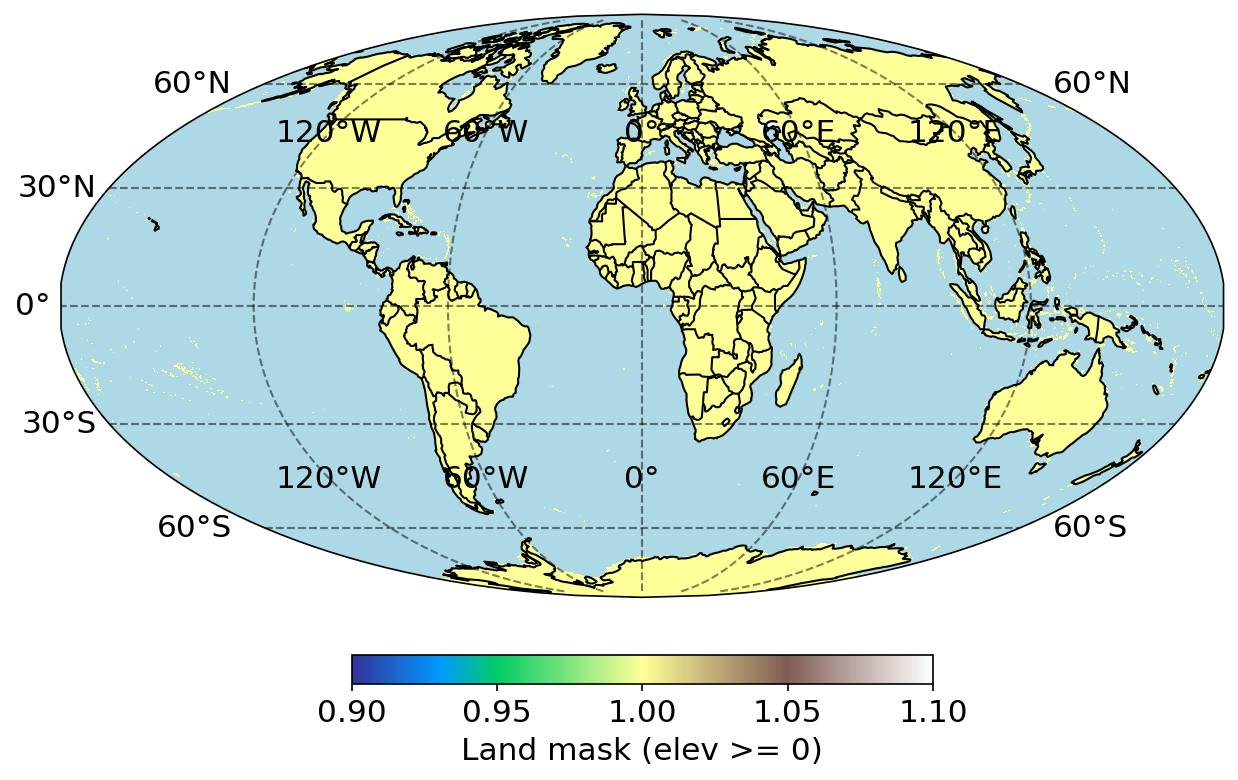

In [2]:
# Create land mask using DEM
domain_lon, domain_lat = hGrid.generate_lon_lat_eqdgrid(0.25)

DEM_path = '/home/nayoung/nas_data/DEM'
Find_DEM_File = sorted(glob.glob(os.path.join(DEM_path, "*.nc")))
DEM_25km = nc.Dataset(Find_DEM_File[0])
with nc.Dataset(Find_DEM_File[0]) as ds:
    DEM_elev = ds.variables['elev'][:]      # (lat, lon)
    lat  = ds.variables['lat'][:]       # (lat,)
    lon  = ds.variables['lon'][:]       # (lon,)

land_mask = DEM_elev > 0
land_only = np.where(land_mask, 1, np.nan)

# Check the land mask for the entire world
hPlot.plot_map(domain_lon, domain_lat, land_only, np.nanmin(land_only), 1, plot_title="Land mask (elev >= 0)", label_title="Land mask (elev >= 0)", cmap='terrain')

# Extract the pixels in the range of 60N~90N
lat_mask_idx = np.where(lat >= 60)[0]

# Cut the pixels in the range of 60N~90N
elev_np = DEM_elev.filled(np.nan)  
elev_60N = elev_np[lat_mask_idx, :]

land_mask_60N_base = np.isfinite(elev_60N).astype(np.uint8) 

## Build a pixel–year DataFrame from pixels where both MOD and MED are valid, then attach TB regime cluster labels
This section constructs a pixel–year DataFrame using only pixels where both Pettitt-derived MOD and MED are available. The objective is to create a consistent dataset for subsequent analysis by ensuring that both target variables are defined for the same set of samples.

For each pixel–year sample, spatial indices (i, j) are derived from latitude and longitude, and the corresponding TB regime cluster label (tb_cluster) is assigned. Only clusters 0–2 are retained, excluding cluster 3 and invalid pixels.
The resulting DataFrame serves as the foundation for cluster-wise analysis of melt timing.

### Define functions

In [3]:
def iter_valid_profiles(ds, land_mask):
    tb = ds["tb_clim"]  # (lat, lon, doy)
    H, W, N_DOY = tb.shape
    for i in range(H):
        row = np.array(tb[i, :, :], dtype=np.float32)  # (W, N_DOY)
        for j in range(W):
            if land_mask[i, j] != 1:
                continue
            prof = row[j, :]
            if np.any(~np.isfinite(prof)):
                continue
            yield i, j, prof

def batcher(gen, batch_size):
    X, IJ = [], []
    for i, j, prof in gen:
        X.append(prof)
        IJ.append((i, j))
        if len(X) == batch_size:
            yield np.stack(X, axis=0), np.array(IJ, dtype=np.int32)
            X, IJ = [], []
    if X:
        yield np.stack(X, axis=0), np.array(IJ, dtype=np.int32)


def latlon_to_ij(lat_vals, lon_vals, lat, lon): # Convert lat/lon arrays to nearest grid indices (i,j).
    lat_vals = np.asarray(lat_vals)
    lon_vals = np.asarray(lon_vals)

    # Latitude is descending
    lat_desc = lat_vals[0] > lat_vals[-1]

    if lat_desc:
        lat_rev = lat_vals[::-1]
        i = np.searchsorted(lat_rev, lat)
        i = (len(lat_vals) - 1) - np.clip(i, 0, len(lat_vals)-1)
    else:
        i = np.searchsorted(lat_vals, lat)
        i = np.clip(i, 0, len(lat_vals)-1)

    # Longitude is ascending
    j = np.searchsorted(lon_vals, lon)
    j = np.clip(j, 0, len(lon_vals)-1)

    return i.astype(np.int32), j.astype(np.int32)


def doy_slice(prof, d0, d1):
    # DOY 1-based, inclusive
    return prof[d0-1:d1]
    

In [4]:
def load_mask_for_year(year):
    """1988–1991 → Use 1992 mask, otherwise use the year."""
    mask_year = max(year, 1992)
    mask_file = os.path.join(
        Permafrost_waterbody_mask_dir,
        f'Permafrost_waterbody_mask_25km_{mask_year}.nc'
    )
    if not os.path.exists(mask_file):
        raise FileNotFoundError(mask_file)

    with nc.Dataset(mask_file, 'r') as ds_mask:
        snowice_mask = np.ma.filled(ds_mask['snowice_mask'][:], np.nan)
        water_mask   = np.ma.filled(ds_mask['water_mask'][:], np.nan)

    # True = mask out
    combined_invalid = np.isnan(snowice_mask) | np.isnan(water_mask)
    return combined_invalid

def pick_var(ds, candidates):
    for name in candidates:
        if name in ds.variables:
            return name
    raise KeyError(f"None of {candidates} found in file: {getattr(ds, 'filepath', lambda: 'unknown')()}")

### Identify valid pixels where both Pettitt-derived MOD and MED are available

In [5]:
# Define the paths and years
Permafrost_waterbody_mask_dir = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/LULC/Permafrost_waterbody_mask'
Pettitt_MOD_filepath = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/MOD_MED/MOD_pettitt_250window_MA5_meanstd_1988_2022.nc'
Pettitt_MED_filepath = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/MOD_MED/MED_pettitt_250window_MA5_meanstd_1988_2022.nc'
start_year, end_year = 1988, 2022

MOD_MED_both_valid_by_year = {}

with nc.Dataset(Pettitt_MOD_filepath, 'r') as dmod, nc.Dataset(Pettitt_MED_filepath, 'r') as dmed:
    lat_name = 'lat' if 'lat' in dmod.variables else ('latitude' if 'latitude' in dmod.variables else None)
    lon_name = 'lon' if 'lon' in dmod.variables else ('longitude' if 'longitude' in dmod.variables else None)
    if lat_name is None or lon_name is None:
        raise KeyError("lat/lon variables not found in MOD file")

    lat = dmod[lat_name][:]
    lon = dmod[lon_name][:]
    LON, LAT = np.meshgrid(lon, lat)

    mod_var = pick_var(dmod, ['MOD_doy', 'MOD_DOY', 'MOD'])
    med_var = pick_var(dmed, ['MED_doy', 'MED_DOY', 'MED'])

    # iterate years
    for year in range(start_year, end_year + 1):
        yi = year - start_year
        if yi < 0 or yi >= dmod[mod_var].shape[2] or yi >= dmed[med_var].shape[2]:
            continue

        mod = np.ma.filled(dmod[mod_var][:, :, yi], np.nan).astype(np.float32)
        med = np.ma.filled(dmed[med_var][:, :, yi], np.nan).astype(np.float32)

        combined_invalid = load_mask_for_year(year)

        valid = (
            (LAT >= 60.0) &
            (~combined_invalid) &
            np.isfinite(mod) &
            np.isfinite(med)
        )

        ii, jj = np.where(valid)
        if ii.size == 0:
            print(f"{year}: 0 pixels with both MOD & MED valid")
            continue

        # Save: lat, lon, mod, med 
        out = np.column_stack([
            LAT[ii, jj],
            LON[ii, jj],
            mod[ii, jj],
            med[ii, jj],
        ]).astype(np.float32)

        MOD_MED_both_valid_by_year[year] = out
        print(f"{year}: {out.shape[0]} pixels with both MOD & MED valid")

print("Done.")

1988: 40111 pixels with both MOD & MED valid
1989: 40111 pixels with both MOD & MED valid
1990: 40111 pixels with both MOD & MED valid
1991: 40110 pixels with both MOD & MED valid
1992: 40111 pixels with both MOD & MED valid
1993: 40111 pixels with both MOD & MED valid
1994: 40111 pixels with both MOD & MED valid
1995: 40105 pixels with both MOD & MED valid
1996: 40097 pixels with both MOD & MED valid
1997: 40097 pixels with both MOD & MED valid
1998: 40095 pixels with both MOD & MED valid
1999: 40092 pixels with both MOD & MED valid
2000: 40078 pixels with both MOD & MED valid
2001: 40081 pixels with both MOD & MED valid
2002: 40077 pixels with both MOD & MED valid
2003: 40078 pixels with both MOD & MED valid
2004: 40075 pixels with both MOD & MED valid
2005: 40076 pixels with both MOD & MED valid
2006: 40078 pixels with both MOD & MED valid
2007: 40077 pixels with both MOD & MED valid
2008: 40075 pixels with both MOD & MED valid
2009: 40074 pixels with both MOD & MED valid
2010: 4007

### Build a pixel-year DataFrame from pixels where both MOD and MED are valid, then attach TB regime cluster labels

In [6]:
# Define the paths and parameters used for cluster construction (same as in the previous code; see Main/Figure1_Create_Clusters.ipynb)
TB_CLIM_PATH = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Clusters/TB_climatology_1988_2022.nc"
N_CLUSTERS = 4
N_COMPONENTS = 5
BATCH = 4096
RANDOM_STATE = 42

# 1. Build TB difference regime cluster map
with nc.Dataset(TB_CLIM_PATH, "r") as ds:
    tb = ds["tb_clim"]
    lat_arr = ds["lat"][:]
    lon_arr = ds["lon"][:]
    H, W, N_DOY = tb.shape

    if land_mask_60N_base.shape != (H, W):
        raise ValueError(f"Mask shape mismatch: mask={land_mask_60N_base.shape}, tb grid={(H, W)}")

    print("tb_clim shape:", tb.shape)

    # 1) StandardScaler: partial_fit on all valid pixels
    scaler = StandardScaler(with_mean=True, with_std=True)
    n_total = 0
    for Xb, _ in batcher(iter_valid_profiles(ds, land_mask_60N_base), BATCH):
        scaler.partial_fit(Xb)
        n_total += Xb.shape[0]
    if n_total == 0:
        raise RuntimeError("No valid pixels found for clustering.")
    print("Total valid pixels used (ALL):", n_total)

    # 2) IncrementalPCA: partial_fit on all valid pixels
    ipca = IncrementalPCA(n_components=N_COMPONENTS, batch_size=BATCH)
    for Xb, _ in batcher(iter_valid_profiles(ds, land_mask_60N_base), BATCH):
        Xz = scaler.transform(Xb)
        ipca.partial_fit(Xz)
    print("IncrementalPCA fitted on ALL valid pixels.")

    # 3) MiniBatchKMeans: partial_fit on all valid pixels
    mbk = MiniBatchKMeans(
        n_clusters=N_CLUSTERS,
        random_state=RANDOM_STATE,
        batch_size=BATCH,
        n_init="auto"
    )
    for Xb, _ in batcher(iter_valid_profiles(ds, land_mask_60N_base), BATCH):
        Xz = scaler.transform(Xb)
        Z = ipca.transform(Xz)
        mbk.partial_fit(Z)
    print("MiniBatchKMeans fitted on ALL valid pixels.")

    # 4) Predict full TB difference cluster map (batch predict)
    tb_cluster_map = np.full((H, W), -1, dtype=np.int16)
    for Xb, IJb in batcher(iter_valid_profiles(ds, land_mask_60N_base), BATCH):
        Xz = scaler.transform(Xb)
        Z = ipca.transform(Xz)
        labs = mbk.predict(Z).astype(np.int16)

        # vectorized assignment
        ii = IJb[:, 0].astype(np.int32)
        jj = IJb[:, 1].astype(np.int32)
        tb_cluster_map[ii, jj] = labs

    valid_clusters = np.unique(tb_cluster_map[tb_cluster_map >= 0])
    print("Cluster map created. Unique clusters:", valid_clusters)


# 2. Build a pixel-year DataFrame from pixels where both MOD and MED are valid, then attach TB regime cluster labels
with nc.Dataset(TB_CLIM_PATH, "r") as ds:
    tb_clim = ds["tb_clim"][:]   # (H, W, 365)

df_list = []
for year, arr in MOD_MED_both_valid_by_year.items():
    if arr is None or arr.size == 0:
        continue

    df = pd.DataFrame(arr, columns=["lat", "lon", "MOD_doy", "MED_doy"])
    df["year"] = int(year)

    # Convert latitude/longitude to grid indices (i, j)
    ii, jj = latlon_to_ij(lat_arr, lon_arr, df["lat"].values, df["lon"].values)
    df["i"] = ii
    df["j"] = jj

    # Attach TB regime cluster labels
    df["tb_cluster"] = tb_cluster_map[ii, jj].astype(np.int16)

    # Retain only clusters 0–2 (exclude cluster 3 and invalid pixels)
    df = df[df["tb_cluster"].isin([0, 1, 2])].reset_index(drop=True)

    if len(df) > 0:
        df_list.append(df)

if not df_list:
    raise RuntimeError("No pixel-year rows after attaching TB clusters (0–2).")

df_all_years = pd.concat(df_list, ignore_index=True)
print("pixel-year rows (clusters 0–2):", df_all_years.shape)

# 3. Build the final feature table for analysis
df_feat = df_all_years.copy()
TARGET_COLS = ["MOD_doy", "MED_doy"]
df_feat = df_feat.dropna(subset=TARGET_COLS).reset_index(drop=True)
print("After dropping NaN targets:", len(df_feat))
print("tb_cluster counts:\n", df_feat["tb_cluster"].value_counts().sort_index())

df_feat.head()

tb_clim shape: (120, 1440, 365)


Total valid pixels used (ALL): 45866
IncrementalPCA fitted on ALL valid pixels.
MiniBatchKMeans fitted on ALL valid pixels.
Cluster map created. Unique clusters: [0 1 2 3]
pixel-year rows (clusters 0–2): (1402846, 8)
After dropping NaN targets: 1402846
tb_cluster counts:
 tb_cluster
0    499791
1    418487
2    484568
Name: count, dtype: int64


,lat,lon,MOD_doy,MED_doy,year,i,j,tb_cluster
0,83.375,-37.375,97.0,202.0,1988,26,570,0
1,83.375,-32.375,98.0,99.0,1988,26,590,0
2,83.375,-31.875,104.0,110.0,1988,26,592,0
3,83.375,-31.625,98.0,99.0,1988,26,593,0
4,83.375,-31.125,104.0,110.0,1988,26,595,0


## Generate pixel–time DataFrame for a given year
This section constructs a pixel–time DataFrame for a selected year by integrating multiple datasets. The goal is to build a comprehensive feature table that combines environmental variables with spatial masks.

The DataFrame is generated by incorporating:
- ERA5-Land dynamic variables (time-varying atmospheric and surface conditions)
- GMTED static topographic variables (elevation, slope, aspect)
- HWSD static soil variables (soil texture properties)

In addition, mask datasets (ocean, permafrost, and waterbody) are applied to exclude invalid regions.
Rather than being merged as features, these masks are used to filter out non-relevant pixels, ensuring that only valid land-based snow regions are retained in the analysis.

The resulting outputs include:
- A pixel–time feature table (df_X) corresponding 2D latitude and longitude grids
- The total number of time steps for the selected year

### Function for constructing a pixel-time DataFrame

In [7]:
def gen_X_df(
    year,
    era5_land_folder_path,
    GMTED_folder_path,
    HWSD_file_list,
    HWSD_folder_path,
    cpuserver_data_FP,
    ERA5_keep_vars_list=None,
    GMTED_keep_vars_list=None,
    HWSD_keep_vars_list=None,
):

    if ERA5_keep_vars_list is None:
        ERA5_keep_vars_list = [
            "u10_mean", "v10_mean", "t2m_mean",
            "stl1_mean", "swvl1_mean",
            "ssr_acc", "asn_mean",
            "lai_hv_mean", "lai_lv_mean",
            "tp_acc"
        ]

    if GMTED_keep_vars_list is None:
        GMTED_keep_vars_list = [
            "elevation", "slope", "aspectcosine"
        ]

    if HWSD_keep_vars_list is None:
        HWSD_keep_vars_list = [
            "T_SAND, T_CLAY, T_SILT"
        ]

    remove_vars_list = ["lat", "lon", "time", "latitude", "longitude"]

    df_X = pd.DataFrame()

    # 1. Define the ERA5 file path and reference mask (Pixels with NaN values are interpreted as ocean)
    era5_land_file_path = os.path.join(
        era5_land_folder_path,
        f"ERA5_Land_Daily_Above_60N_{year}.nc"
    )
    if not os.path.exists(era5_land_file_path):
        raise FileNotFoundError(f"ERA5 file not found: {era5_land_file_path}")

    ref_path = os.path.join(
        era5_land_folder_path,
        "ERA5_Land_Daily_Above_60N_2022.nc"
    )
    if not os.path.exists(ref_path):
        raise FileNotFoundError(f"Reference file for ocean mask not found: {ref_path}")


    # 2. Ocean mask from reference year
    with nc.Dataset(ref_path) as ds_ref:
        ref_vars = [
            v for v in ds_ref.variables.keys()
            if v not in remove_vars_list
        ]
        if len(ref_vars) == 0:
            raise RuntimeError("No usable variable found in ERA5 reference file.")

        ref_var = ref_vars[0]
        ref_data = ds_ref.variables[ref_var][:]

        if ref_data.ndim == 3:
            ocean_mask_land = np.where(np.isnan(ref_data[:, :, 0]), 0, 1).astype(np.uint8)
        elif ref_data.ndim == 2:
            ocean_mask_land = np.where(np.isnan(ref_data[:, :]), 0, 1).astype(np.uint8)
        else:
            raise RuntimeError(f"Unexpected reference variable shape: {ref_data.shape}")


    # 3. Load ERA5-Land data
    with nc.Dataset(era5_land_file_path) as ds:
        lat_raw = ds.variables["latitude"][:]
        lon_raw = ds.variables["longitude"][:]

        # Support both 1D and 2D lat/lon
        if lat_raw.ndim == 1 and lon_raw.ndim == 1:
            lat2d, lon2d = np.meshgrid(lat_raw, lon_raw, indexing="ij")
        elif lat_raw.ndim == 2 and lon_raw.ndim == 2:
            lat2d = lat_raw
            lon2d = lon_raw
        else:
            raise RuntimeError("Unexpected ERA5 latitude/longitude dimensions.")

        nlat, nlon = lat2d.shape

        era5_vars = [
            v for v in ds.variables.keys()
            if v not in remove_vars_list and v in ERA5_keep_vars_list
        ]
        if len(era5_vars) == 0:
            raise RuntimeError("No ERA5 variables matched ERA5_keep_vars_list.")

        sample = ds.variables[era5_vars[0]][:]
        if sample.ndim == 3:
            _, _, time_length = sample.shape
        else:
            time_length = ds.dimensions["time"].size

        spatial_size = nlat * nlon

        # Build i, j indices
        i2d, j2d = np.indices((nlat, nlon))
        i_flat = i2d.reshape(-1)
        j_flat = j2d.reshape(-1)

        # Flatten coordinates
        lat_flat_2d = lat2d.reshape(-1)
        lon_flat_2d = lon2d.reshape(-1)

        # Include i, j, year
        df_X["i"] = np.repeat(i_flat, time_length).astype(np.int32)
        df_X["j"] = np.repeat(j_flat, time_length).astype(np.int32)
        df_X["latitude"] = np.repeat(lat_flat_2d, time_length)
        df_X["longitude"] = np.repeat(lon_flat_2d, time_length)
        df_X["year"] = np.full(spatial_size * time_length, year, dtype=np.int16)
        df_X["time_idx"] = np.tile(np.arange(time_length, dtype=np.int32), spatial_size)

        # Read selected ERA5 variables only
        for var in era5_vars:
            data = ds.variables[var][:]

            if data.ndim == 3:
                if data.shape != (nlat, nlon, time_length):
                    raise RuntimeError(f"ERA5 variable {var} shape mismatch: {data.shape}")
                df_X[var] = np.ma.filled(data, np.nan).reshape(-1)

            elif data.ndim == 2:
                if data.shape != (nlat, nlon):
                    raise RuntimeError(f"ERA5 variable {var} 2D shape mismatch: {data.shape}")
                df_X[var] = np.repeat(np.ma.filled(data, np.nan).reshape(-1), time_length)

            else:
                print(f"[WARN] Skip ERA5 variable {var}: unexpected ndim={data.ndim}")


    # 4. Load GMTED static variables
    all_gmted_files = [
        f for f in os.listdir(GMTED_folder_path)
        if f.endswith(".nc") and not f.startswith(".")
    ]

    gmted_file_map = {}
    for keep_var in GMTED_keep_vars_list:
        matched = [f for f in all_gmted_files if f.startswith(keep_var + "_")]
        if len(matched) == 0:
            print(f"[WARN] GMTED file not found for variable: {keep_var}")
        elif len(matched) > 1:
            print(f"[WARN] Multiple GMTED files matched {keep_var}: {matched}. Using the first one.")
            gmted_file_map[keep_var] = matched[0]
        else:
            gmted_file_map[keep_var] = matched[0]

    for out_var, file in gmted_file_map.items():
        path = os.path.join(GMTED_folder_path, file)

        with nc.Dataset(path) as ds_g:
            data_vars = [
                v for v in ds_g.variables.keys()
                if v not in remove_vars_list
            ]
            if len(data_vars) == 0:
                print(f"[WARN] No data variable found in GMTED file: {file}")
                continue

            data_var = data_vars[0]
            arr = ds_g.variables[data_var][:]

            if arr.ndim == 3 and arr.shape[2] == 1:
                arr2d = arr[:, :, 0]
            elif arr.ndim == 2:
                arr2d = arr
            else:
                print(f"[WARN] GMTED {file} has unexpected shape {arr.shape}, skip.")
                continue

            arr2d = np.ma.filled(arr2d, np.nan)

            if arr2d.shape != (nlat, nlon):
                print(f"[WARN] GMTED {file} shape {arr2d.shape} != ({nlat}, {nlon}), skip.")
                continue

            df_X[out_var] = np.repeat(arr2d.reshape(-1), time_length)


    # 5. Load HWSD static variables
    for file in HWSD_file_list:
        path = os.path.join(HWSD_folder_path, file)

        with nc.Dataset(path) as ds_h:
            hwsd_vars = [
                v for v in ds_h.variables.keys()
                if v not in remove_vars_list and v in HWSD_keep_vars_list
            ]

            for var in hwsd_vars:
                arr = ds_h.variables[var][:]

                if arr.ndim == 3 and arr.shape[2] == 1:
                    arr2d = arr[:, :, 0]
                elif arr.ndim == 2:
                    arr2d = arr
                else:
                    print(f"[WARN] HWSD variable {var} has unexpected shape {arr.shape}, skip.")
                    continue

                arr2d = np.ma.filled(arr2d, np.nan)

                if arr2d.shape != (nlat, nlon):
                    print(f"[WARN] HWSD variable {var} shape {arr2d.shape} != ({nlat}, {nlon}), skip.")
                    continue

                df_X[var] = np.repeat(arr2d.reshape(-1), time_length)


    # 6. Load Permafrost / waterbody mask + ocean mask
    permafrost_waterbody_folder_path = os.path.join(
        cpuserver_data_FP,
        "personal_data/project_snow/MOD/Permafrost_waterbody_mask"
    )

    mask_this = os.path.join(
        permafrost_waterbody_folder_path,
        f"Permafrost_waterbody_mask_25km_{year}.nc"
    )

    if os.path.exists(mask_this):
        with nc.Dataset(mask_this) as ds_m:
            snowice_mask = ds_m.variables["snowice_mask"][:]
            water_mask = ds_m.variables["water_mask"][:]
    else:
        fb = os.path.join(
            permafrost_waterbody_folder_path,
            "Permafrost_waterbody_mask_25km_1992.nc"
        )
        if os.path.exists(fb):
            print(f"[INFO] {mask_this} not found -> using 1992 fallback mask.")
            with nc.Dataset(fb) as ds_m:
                snowice_mask = ds_m.variables["snowice_mask"][:]
                water_mask = ds_m.variables["water_mask"][:]
        else:
            print("[WARN] No permafrost/waterbody mask found. Using ocean mask only.")
            snowice_mask = np.ones_like(ocean_mask_land, dtype=np.uint8)
            water_mask = np.ones_like(ocean_mask_land, dtype=np.uint8)

    if snowice_mask.shape != (nlat, nlon) or water_mask.shape != (nlat, nlon):
        print("[WARN] Mask shape mismatch. Using ocean mask only.")
        keep_2d = (ocean_mask_land == 1).astype(np.uint8)
    else:
        keep_2d = (
            (ocean_mask_land == 1) &
            (snowice_mask == 1) &
            (water_mask == 1)
        ).astype(np.uint8)

    keep_flat = np.repeat(keep_2d.reshape(-1), time_length)

    before = len(df_X)
    df_X = df_X.loc[keep_flat == 1].reset_index(drop=True)
    after = len(df_X)

    print(f"[{year}] Kept {after}/{before} rows after masks.")
    print(f"[{year}] Final columns ({len(df_X.columns)}): {list(df_X.columns)}")

    return df_X, lat2d, lon2d, time_length


### Function for constructing pixel-year features from melt-season dynamic variables and static environmental variables

In [8]:
def build_pixel_features_from_years_doy_window(
    year_list,
    era5_land_folder_path,
    GMTED_folder_path,
    HWSD_file_list, HWSD_folder_path,
    cpuserver_data_FP,
    ERA5_keep_vars_list=None,
    GMTED_keep_vars_list=None,
    HWSD_keep_vars_list=None,
    start_doy=60,
    end_doy=181
):
    if ERA5_keep_vars_list is None:
        ERA5_keep_vars_list = [
            "u10_mean", "v10_mean", "t2m_mean",
            "stl1_mean", "swvl1_mean",
            "ssr_acc", "asn_mean",
            "lai_hv_mean", "lai_lv_mean",
            "tp_acc"
        ]

    if GMTED_keep_vars_list is None:
        GMTED_keep_vars_list = ["elevation", "slope", "aspectcosine"]

    if HWSD_keep_vars_list is None:
        HWSD_keep_vars_list = ["T_SAND", "T_CLAY", "T_SILT"]

    pixel_year_list = []

    for year in year_list:
        print(f"--- Building DOY-window pixel-year features for {year} ---")

        df_X, lat2d, lon2d, time_length = gen_X_df(
            year=year,
            era5_land_folder_path=era5_land_folder_path,
            GMTED_folder_path=GMTED_folder_path,
            HWSD_file_list=HWSD_file_list,
            HWSD_folder_path=HWSD_folder_path,
            cpuserver_data_FP=cpuserver_data_FP,
            ERA5_keep_vars_list=ERA5_keep_vars_list,
            GMTED_keep_vars_list=GMTED_keep_vars_list,
            HWSD_keep_vars_list=HWSD_keep_vars_list,
        )

        # 1. Convert time_idx to DOY
        # ---------------------------
        dates = pd.date_range(f"{year}-01-01", periods=time_length, freq="D")
        time_map = pd.DataFrame({
            "time_idx": np.arange(time_length, dtype=np.int32),
            "doy": dates.dayofyear.astype(np.int16)
        })

        df_X = df_X.merge(time_map, on="time_idx", how="left")

        # Make sure year exists
        if "year" not in df_X.columns:
            df_X["year"] = year

        # 2. Filter DOY window
        df_X = df_X[(df_X["doy"] >= start_doy) & (df_X["doy"] <= end_doy)].copy()

        if df_X.empty:
            print(f"[{year}] No data found within DOY {start_doy}-{end_doy}. Skipping.")
            continue

        # 3. Column groups
        key_cols = ["i", "j", "latitude", "longitude", "year"]

        dynamic_cols = [c for c in ERA5_keep_vars_list if c in df_X.columns]

        static_cont_cols = [
            c for c in (GMTED_keep_vars_list + HWSD_keep_vars_list)
            if c in df_X.columns
        ]


        # 4. Dynamic aggregation over DOY window
        dyn_agg = {c: ["mean", "std"] for c in dynamic_cols}

        df_dyn = (
            df_X
            .groupby(key_cols, as_index=False)
            .agg(dyn_agg)
        )

        # Flatten MultiIndex columns
        df_dyn.columns = [
            "_".join([str(x) for x in col if str(x) != ""]).strip("_")
            if isinstance(col, tuple) else col
            for col in df_dyn.columns
        ]

        # Rename aggregated columns to include DOY window
        rename_dyn = {}
        for c in dynamic_cols:
            if f"{c}_mean" in df_dyn.columns:
                rename_dyn[f"{c}_mean"] = f"{c}_marjun_mean"
            if f"{c}_std" in df_dyn.columns:
                rename_dyn[f"{c}_std"] = f"{c}_marjun_std"

        df_dyn = df_dyn.rename(columns=rename_dyn)

        # 5. Static continuous: attach once per pixel-year
        static_cont_df = None
        if len(static_cont_cols) > 0:
            static_cont_df = (
                df_X[key_cols + static_cont_cols]
                .groupby(key_cols, as_index=False)
                .first()
            )

        # 6. Merge all for this year
        feat_year = df_dyn.copy()

        if static_cont_df is not None:
            feat_year = feat_year.merge(
                static_cont_df,
                on=key_cols,
                how="left",
                validate="one_to_one"
            )


        pixel_year_list.append(feat_year)

        print(f"[{year}] feature shape: {feat_year.shape}")

    if not pixel_year_list:
        raise RuntimeError("No pixel-year features were created.")

    feat_all = pd.concat(pixel_year_list, ignore_index=True)
    print(f"Final DOY-window pixel-year feature shape: {feat_all.shape}")

    return feat_all


### Generate pixel–time DataFrame 

In [9]:
# Define paths and lists
GMTED_folder_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/GMTED2010/Above_60N'
HWSD_folder_path = f'{cpuserver_data_FP}/personal_data/project_snow/MOD/Resampled_HWSD'
era5_land_folder_path = f'{data2_FP}/ERA5_Land//extracted_nc/Above_60N/Revised_ERA5_25km_60N'

GMTED_file_list = os.listdir(GMTED_folder_path)
GMTED_file_list = [file for file in GMTED_file_list if file.endswith('.nc') and not file.startswith('.')]
HWSD_file_list = os.listdir(HWSD_folder_path)
HWSD_file_list = [file for file in HWSD_file_list if file.endswith('.nc') and not file.startswith('.')] # Static
year_list = sorted(list(MOD_MED_both_valid_by_year.keys()))

# Keep variables lists
ERA5_keep_vars_list = [
    "u10_mean", "v10_mean", "t2m_mean",
    "stl1_mean", "swvl1_mean",
    "ssr_acc", "asn_mean",
    "lai_hv_mean", "lai_lv_mean",
    "tp_acc"
]

GMTED_keep_vars_list = ["elevation", "slope", "aspectcosine"]
HWSD_keep_vars_list = ["T_SAND", "T_CLAY", "T_SILT"]

feat_pix = build_pixel_features_from_years_doy_window(
    year_list=year_list,
    era5_land_folder_path=era5_land_folder_path,
    GMTED_folder_path=GMTED_folder_path,
    HWSD_file_list=HWSD_file_list,
    HWSD_folder_path=HWSD_folder_path,
    cpuserver_data_FP=cpuserver_data_FP,
    ERA5_keep_vars_list=ERA5_keep_vars_list,
    GMTED_keep_vars_list=GMTED_keep_vars_list,
    HWSD_keep_vars_list=HWSD_keep_vars_list,
    start_doy=60,
    end_doy=181
)

feat_pix_renamed = feat_pix.rename(columns={"latitude": "lat", "longitude": "lon"}).copy()

# Check uniqueness on the true key
print("right duplicated keys (i, j, year):",
      feat_pix_renamed.duplicated(["i", "j", "year"]).sum())

# Merge melt timing information (Pettitt-derived MOD and MED, along with tb_cluster) with the corresponding pixel-year environmental features
# (many MOD/MED samples map to one feature set per pixel-year)
df_shap = pd.merge(
    df_feat,
    feat_pix_renamed,
    on=["i", "j", "year"],
    how="inner",
    validate="many_to_one"
)

print("before:", len(df_feat), "after:", len(df_shap))
print("drop ratio:", 1 - len(df_shap) / len(df_feat))

df_shap.to_csv(
    f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/SHAP/df_shap_20260412_with_reduced_variables.csv",
    index=False
)

--- Building DOY-window pixel-year features for 1988 ---


[INFO] /home/nayoung/cpuserver_data/personal_data/project_snow/MOD/Permafrost_waterbody_mask/Permafrost_waterbody_mask_25km_1988.nc not found -> using 1992 fallback mask.
[1988] Kept 17555922/63244800 rows after masks.
[1988] Final columns (22): ['i', 'j', 'latitude', 'longitude', 'year', 'time_idx', 't2m_mean', 'stl1_mean', 'asn_mean', 'swvl1_mean', 'ssr_acc', 'u10_mean', 'v10_mean', 'tp_acc', 'lai_hv_mean', 'lai_lv_mean', 'elevation', 'slope', 'aspectcosine', 'T_CLAY', 'T_SAND', 'T_SILT']
[1988] feature shape: (47967, 31)
--- Building DOY-window pixel-year features for 1989 ---
[INFO] /home/nayoung/cpuserver_data/personal_data/project_snow/MOD/Permafrost_waterbody_mask/Permafrost_waterbody_mask_25km_1989.nc not found -> using 1992 fallback mask.
[1989] Kept 17507955/63072000 rows after masks.
[1989] Final columns (22): ['i', 'j', 'latitude', 'longitude', 'year', 'time_idx', 't2m_mean', 'stl1_mean', 'asn_mean', 'swvl1_mean', 'ssr_acc', 'u10_mean', 'v10_mean', 'tp_acc', 'lai_hv_mean', 

### Check if the DataFrame created well

In [10]:
Dataframe_file = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/SHAP/df_shap_20260412_with_reduced_variables.csv"
df= pd.read_csv(Dataframe_file)
df.iloc[:5, :20]

,lat_x,lon_x,MOD_doy,MED_doy,year,i,j,tb_cluster,lat_y,lon_y,u10_mean_marjun_mean,u10_mean_marjun_std,v10_mean_marjun_mean,v10_mean_marjun_std,t2m_mean_marjun_mean,t2m_mean_marjun_std,stl1_mean_marjun_mean,stl1_mean_marjun_std,swvl1_mean_marjun_mean,swvl1_mean_marjun_std
0,83.375,-37.375,97.0,202.0,1988,26,570,0,83.375,-37.375,0.070864,1.814697,0.849111,0.717220,256.00818,10.863983,244.77948,3.856779,0.331708,0.0
1,83.375,-32.375,98.0,99.0,1988,26,590,0,83.375,-32.375,1.545692,1.906452,0.381722,0.916864,255.03937,10.819797,244.76918,4.016445,0.265829,0.0
2,83.375,-31.875,104.0,110.0,1988,26,592,0,83.375,-31.875,1.554680,1.898394,0.405787,0.909355,255.34682,10.927299,244.69374,4.047905,0.272896,0.0
3,83.375,-31.625,98.0,99.0,1988,26,593,0,83.375,-31.625,1.560314,1.902461,0.420185,0.910603,255.50935,10.975521,244.64485,4.059870,0.276050,0.0
4,83.375,-31.125,104.0,110.0,1988,26,595,0,83.375,-31.125,1.569906,1.945095,0.470385,0.927522,255.78351,11.025270,245.21884,4.023018,0.281291,0.0


## SHAP Analysis
Based on the constructed DataFrame, SHAP analysis was conducted separately for Pettitt-derived MOD and Pettitt-derived MED.
For model input features, non-informative or target-related variables were excluded, including:
- temporal information (e.g., year)
- target variables (MOD and MED)
- spatial identifiers (e.g., latitude and longitude, and pixel indices)

This ensures that the SHAP analysis focuses only on environmental features that influence melt timing.

### Figure 6. Top five environmental features influencing Pettitt-test-based MDs

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007325 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6629
[LightGBM] [Info] Number of data points in the train set: 499710, number of used features: 26
[LightGBM] [Info] Start training from score 97.519848


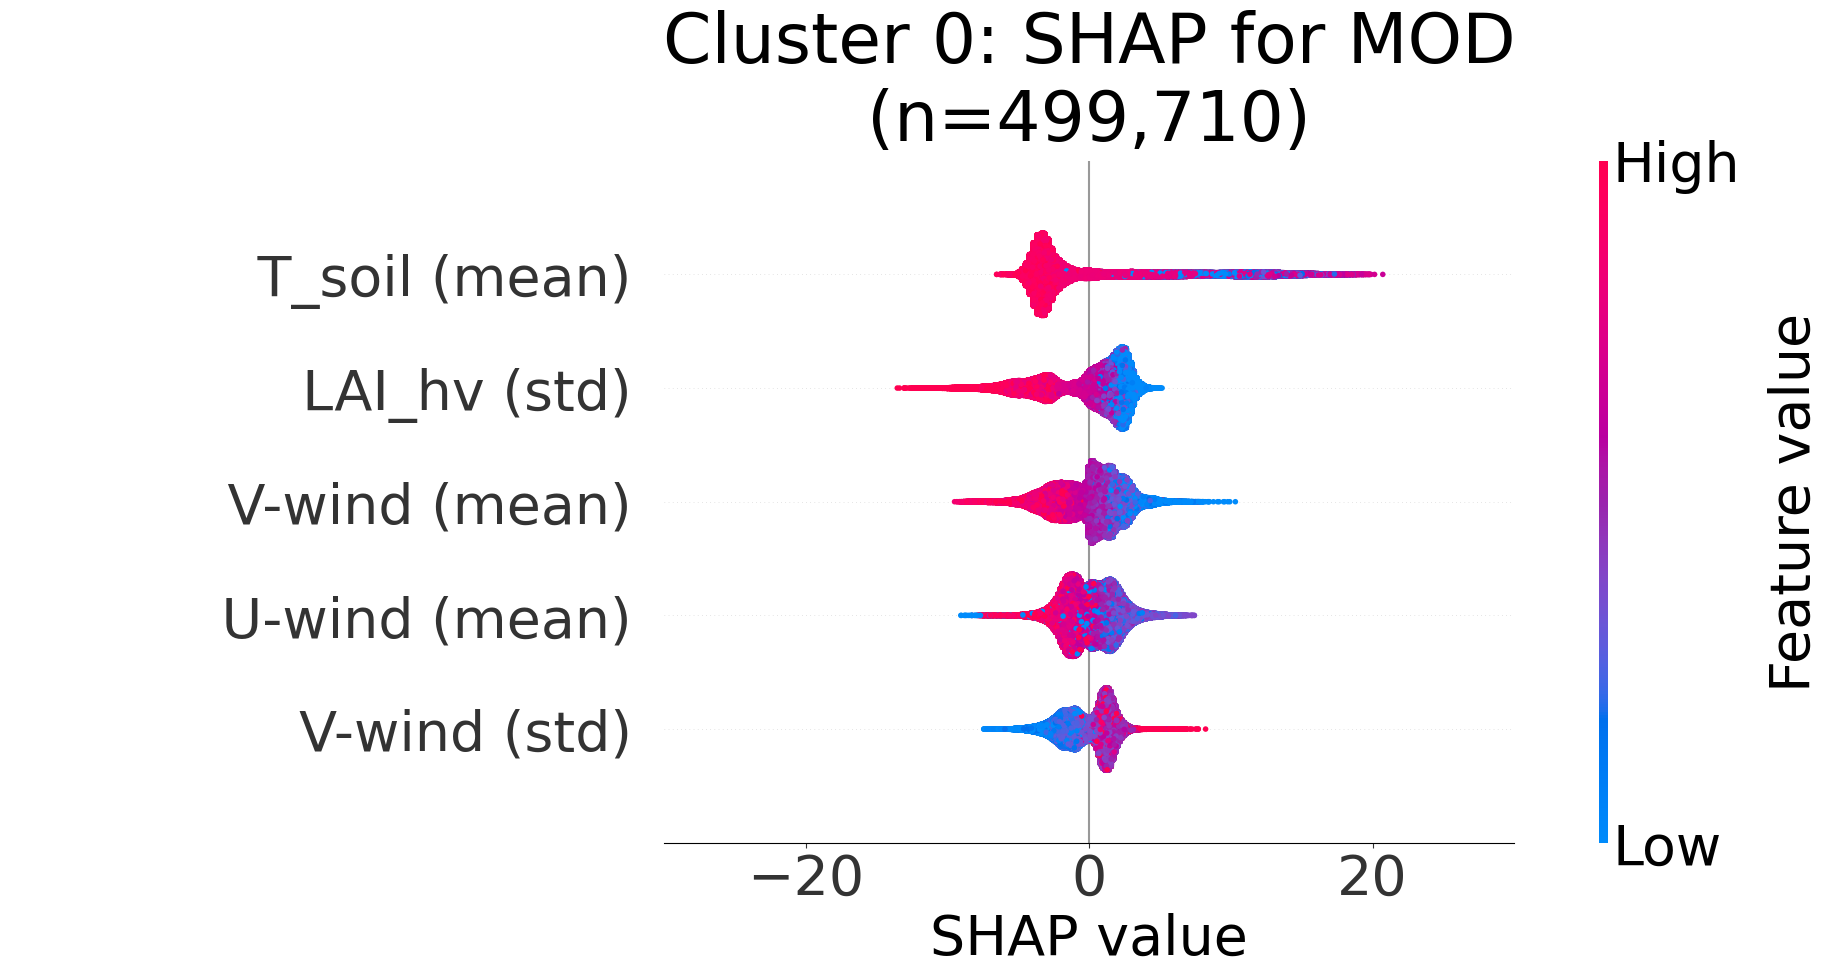

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007193 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6629
[LightGBM] [Info] Number of data points in the train set: 499710, number of used features: 26
[LightGBM] [Info] Start training from score 127.306540


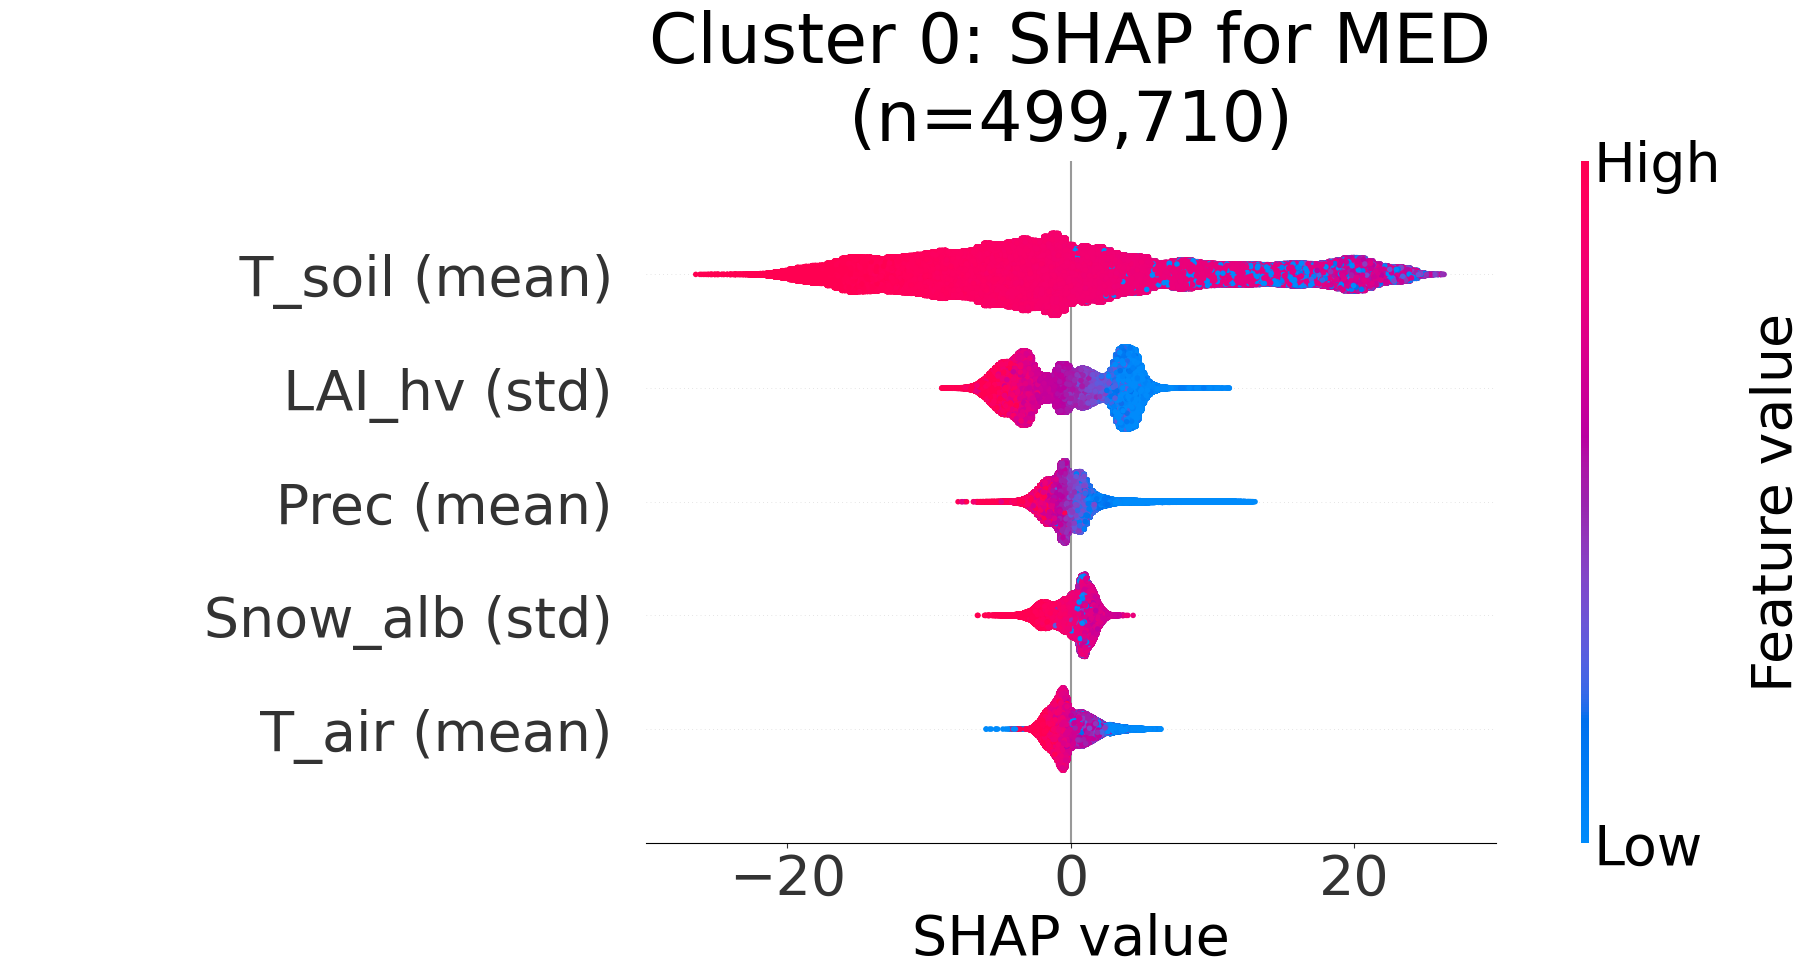

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006035 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6629
[LightGBM] [Info] Number of data points in the train set: 418320, number of used features: 26
[LightGBM] [Info] Start training from score 116.918460


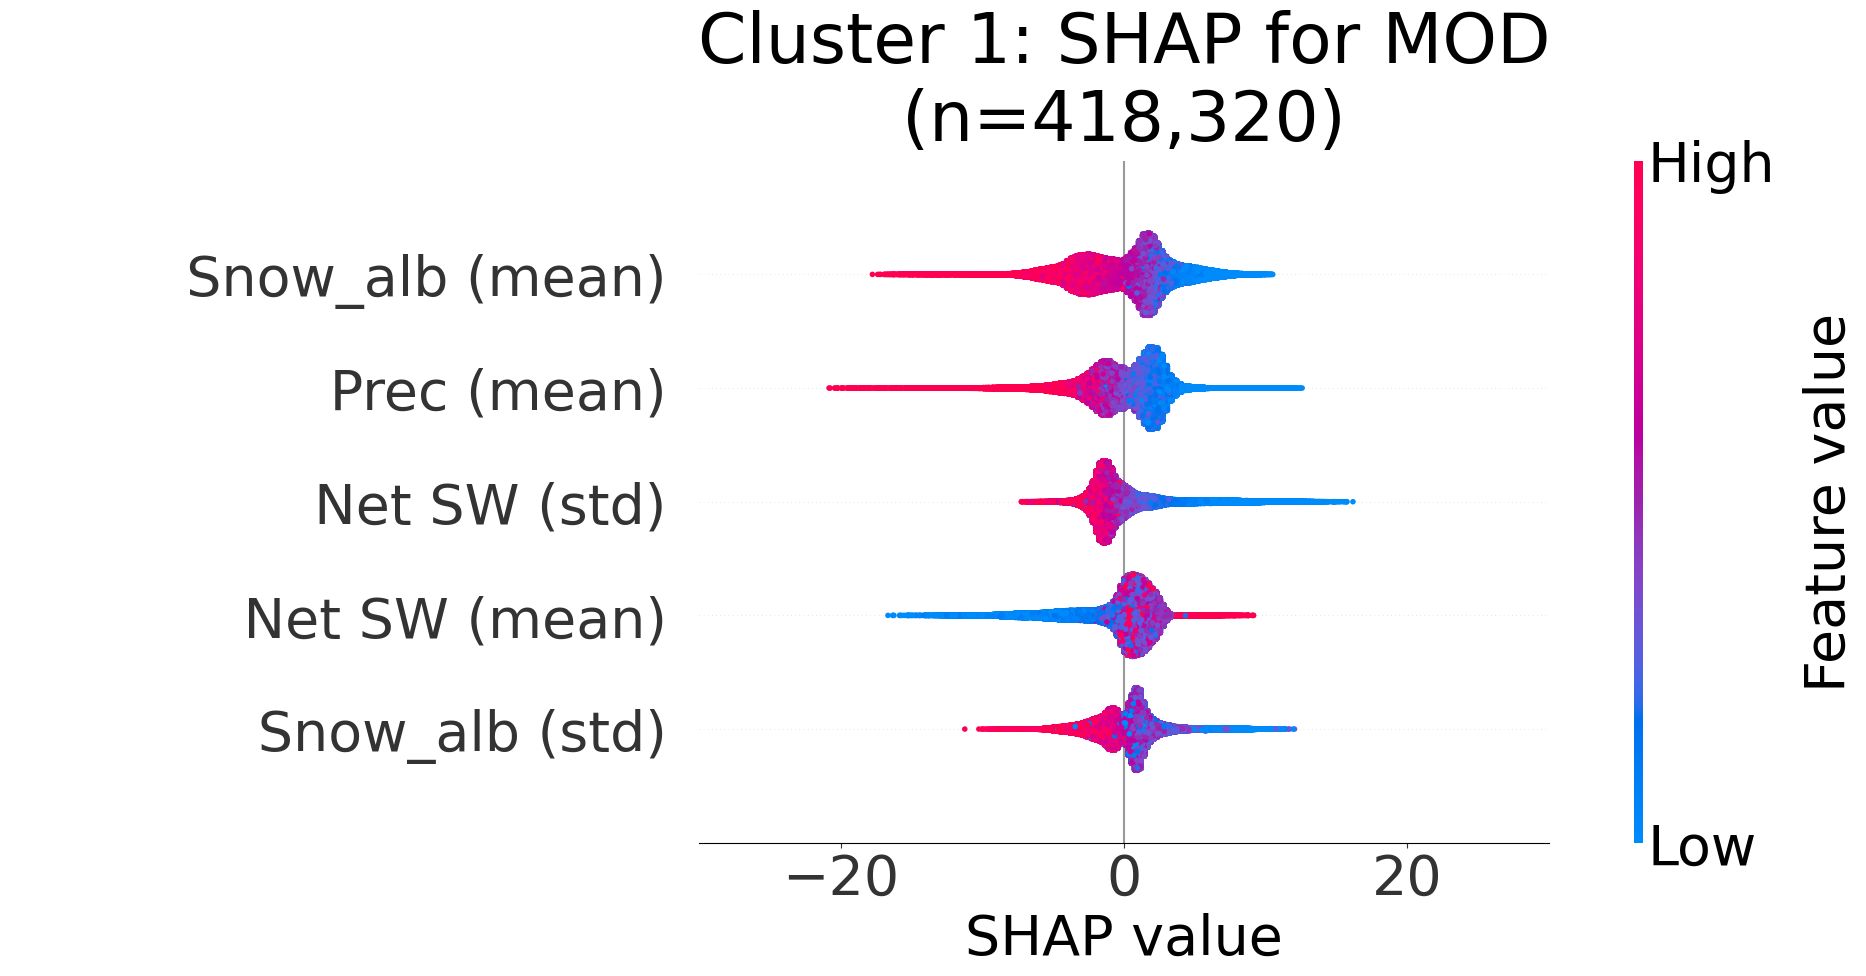

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005494 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6629
[LightGBM] [Info] Number of data points in the train set: 418320, number of used features: 26
[LightGBM] [Info] Start training from score 167.570783


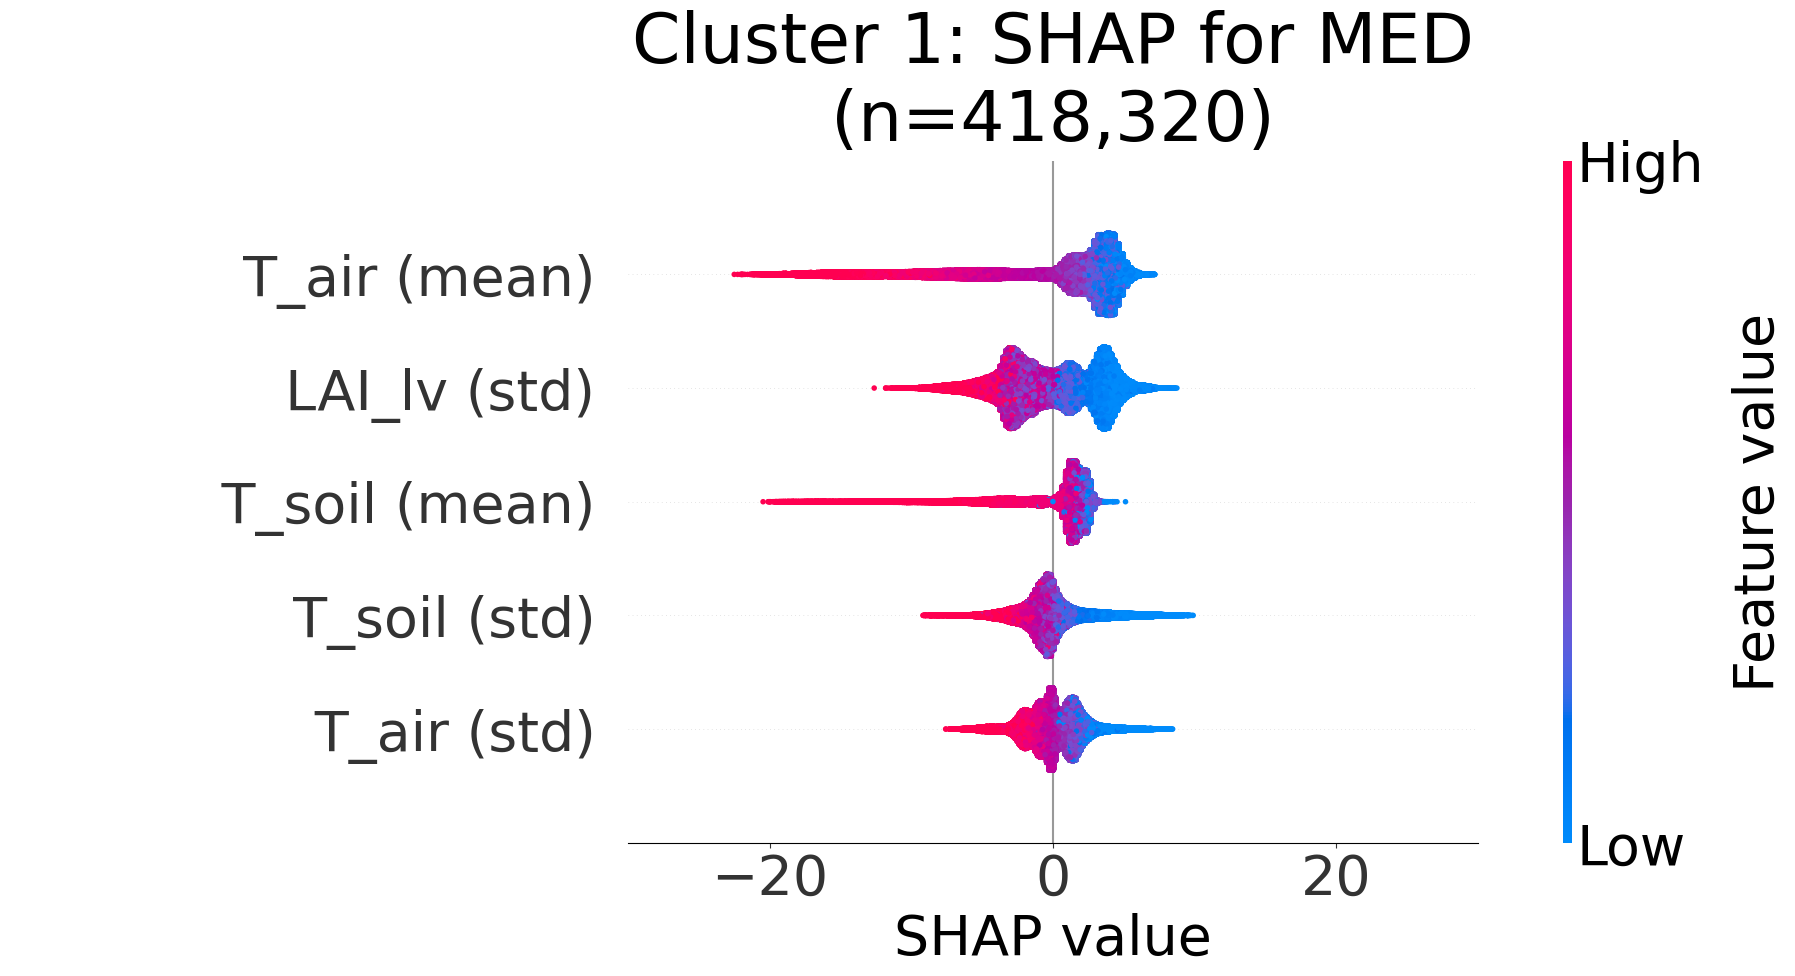

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007877 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6630
[LightGBM] [Info] Number of data points in the train set: 484544, number of used features: 26
[LightGBM] [Info] Start training from score 96.889667


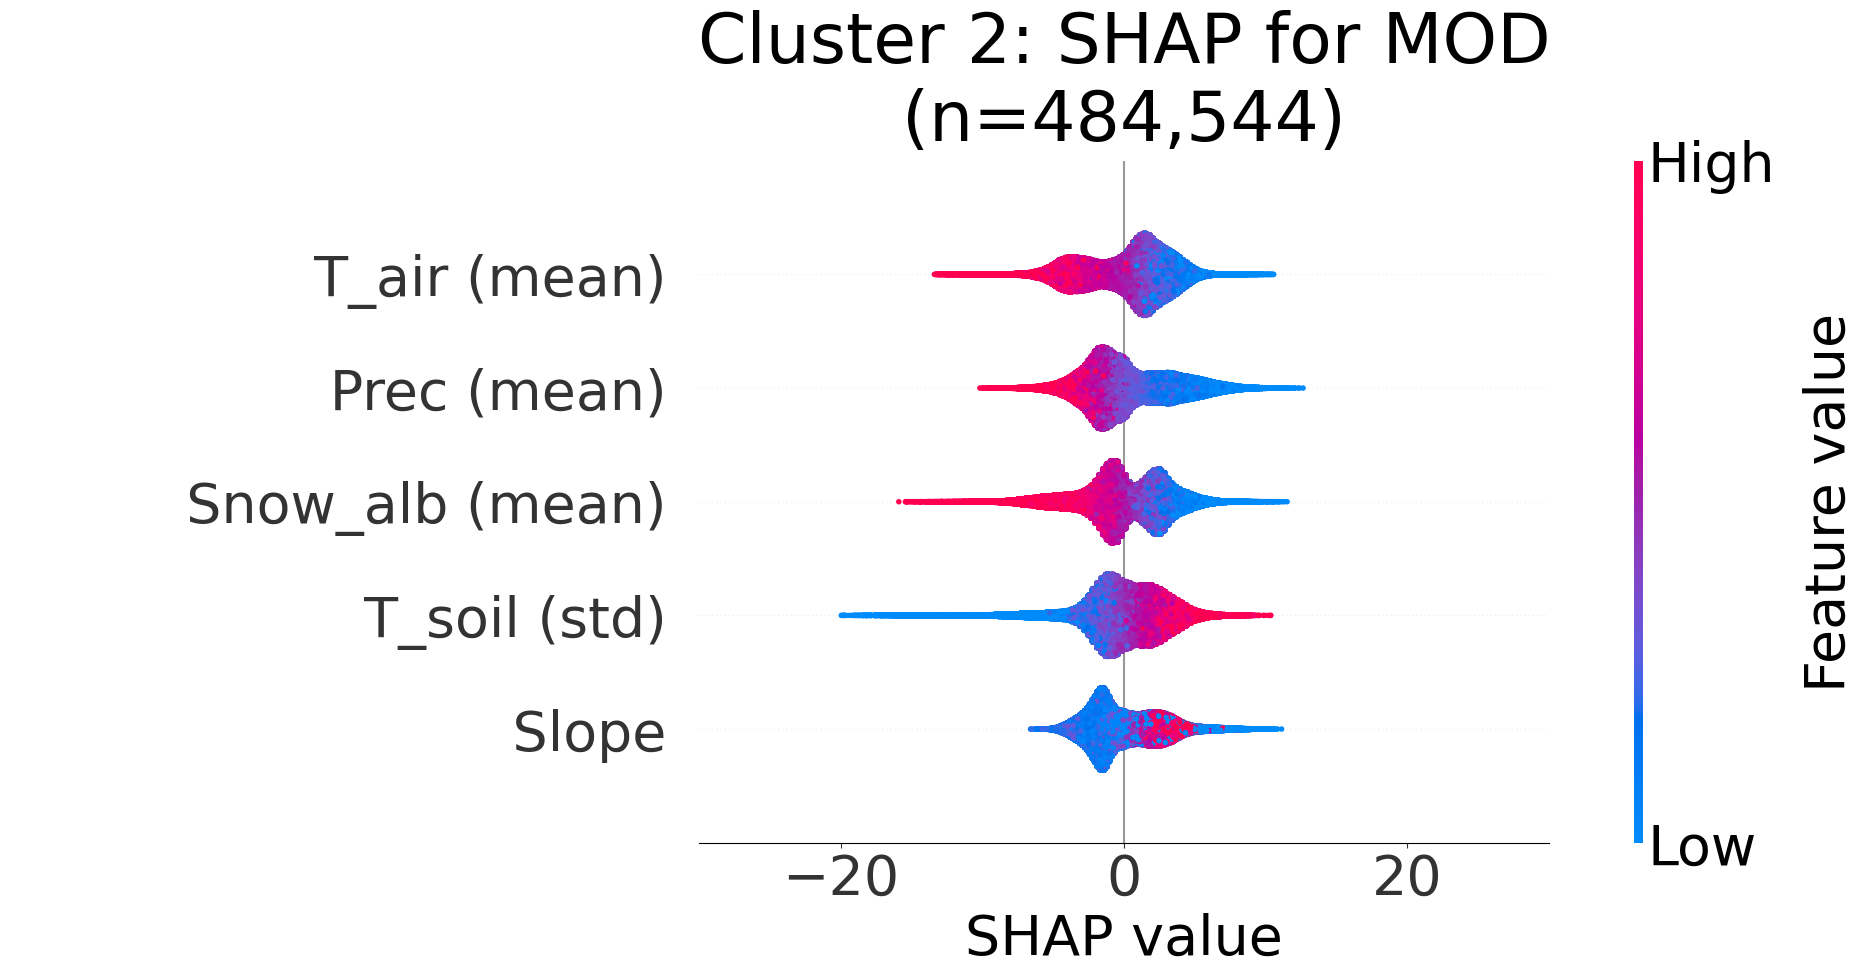

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006301 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6630
[LightGBM] [Info] Number of data points in the train set: 484544, number of used features: 26
[LightGBM] [Info] Start training from score 144.646657


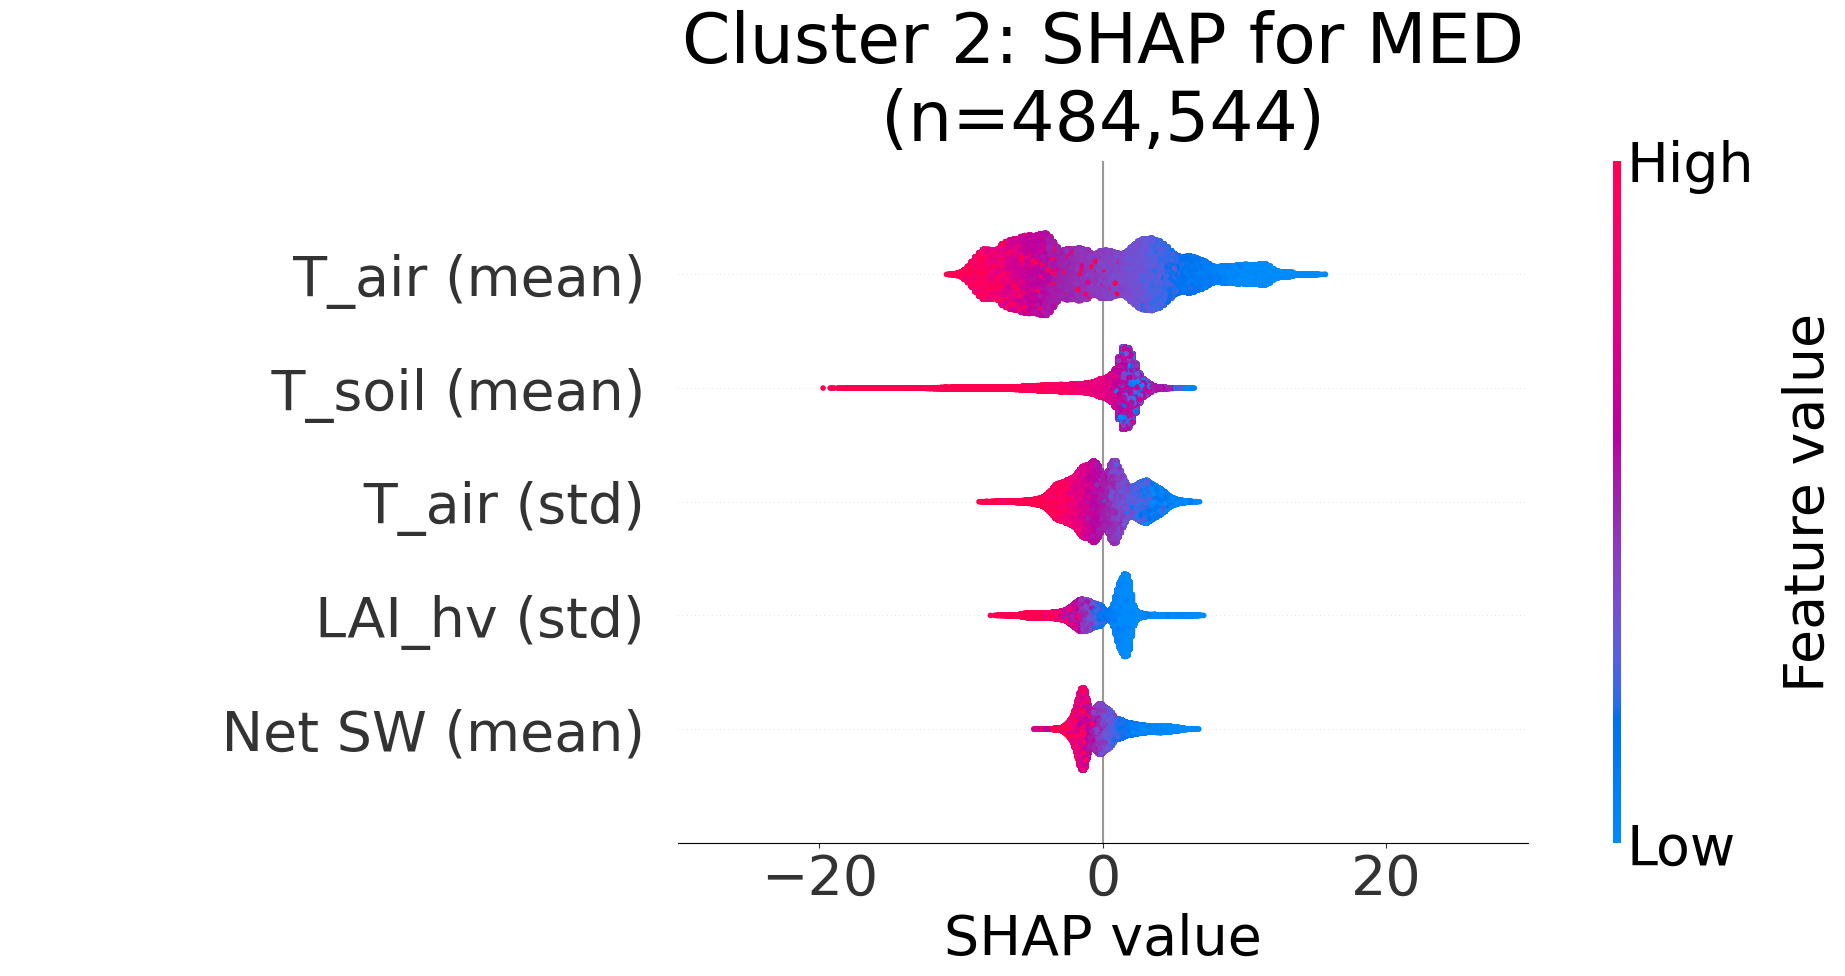


=== All cluster-target top 5 summary ===
    cluster   target  feature_display  mean_abs_shap
0         0  MOD_doy    T_soil (mean)       4.327509
1         0  MOD_doy     LAI_hv (std)       2.412838
2         0  MOD_doy    V-wind (mean)       1.846250
3         0  MOD_doy    U-wind (mean)       1.477637
4         0  MOD_doy     V-wind (std)       1.454887
5         0  MED_doy    T_soil (mean)       8.769734
6         0  MED_doy     LAI_hv (std)       3.182684
7         0  MED_doy      Prec (mean)       1.322565
8         0  MED_doy   Snow_alb (std)       1.181378
9         0  MED_doy     T_air (mean)       1.130384
10        1  MOD_doy  Snow_alb (mean)       2.631797
11        1  MOD_doy      Prec (mean)       2.052810
12        1  MOD_doy     Net SW (std)       1.856172
13        1  MOD_doy    Net SW (mean)       1.748068
14        1  MOD_doy   Snow_alb (std)       1.631038
15        1  MED_doy     T_air (mean)       4.615645
16        1  MED_doy     LAI_lv (std)       2.877791
17  

In [11]:
# Define target variables and exclude columns
target_list = ["MOD_doy", "MED_doy"]
exclude_cols = [
    "year", "MOD_doy", "MED_doy", "i", "j",
    "lat_x", "lon_x", "lat_k", "lon_k", "lat_y", "lon_y"
] + target_list

feature_cols = [
    c for c in df_shap.columns
    if c not in exclude_cols and c not in ["lat", "lon", "tb_cluster"]
]

# Define variable name mapping and padding
max_label_len = 25  # To match the longest variable name
feature_name_map = {
    "elevation": "Elevation", "slope": "Slope", "aspectcosine": "Aspect",
    "T_SAND": "Topsoil sand", "T_CLAY": "Topsoil clay", "T_SILT": "Topsoil silt",
    "t2m_mean_marjun_mean": "T_air (mean)", "t2m_mean_marjun_std": "T_air (std)",
    "asn_mean_marjun_mean": "Snow_alb (mean)", "asn_mean_marjun_std": "Snow_alb (std)",
    "tp_acc_marjun_mean": "Prec (mean)", "tp_acc_marjun_std": "Prec (std)",
    "stl1_mean_marjun_mean": "T_soil (mean)", "stl1_mean_marjun_std": "T_soil (std)",
    "ssr_acc_marjun_mean": "Net SW (mean)", "ssr_acc_marjun_std": "Net SW (std)",
    "lai_hv_mean_marjun_mean": "LAI_hv (mean)", "lai_hv_mean_marjun_std": "LAI_hv (std)",
    "lai_lv_mean_marjun_mean": "LAI_lv (mean)", "lai_lv_mean_marjun_std": "LAI_lv (std)",
    "swvl1_mean_marjun_mean": "SM (mean)", "swvl1_mean_marjun_std": "SM (std)",
    "u10_mean_marjun_mean": "U-wind (mean)", "u10_mean_marjun_std": "U-wind (std)",
    "v10_mean_marjun_mean": "V-wind (mean)", "v10_mean_marjun_std": "V-wind (std)",
}

target_name_map = {"MOD_doy": "MOD", "MED_doy": "MED"}

results = {}
top5_summary = []

# Set font size 
plt.rcParams.update({
    'font.size': 18, 
    'axes.titlesize': 22, 
    'axes.labelsize': 18, 
    'xtick.labelsize': 16, 
    'ytick.labelsize': 16
})

for cid in sorted(df_shap["tb_cluster"].dropna().unique()):
    df_c = df_shap[df_shap["tb_cluster"] == cid].copy()

    if len(df_c) < 300:
        continue

    for target in target_list:
        sub = df_c.dropna(subset=[target] + feature_cols)
        X = sub[feature_cols].copy()
        y = sub[target].copy()

        model = LGBMRegressor(
            n_estimators=600, learning_rate=0.05, subsample=0.8,
            colsample_bytree=0.8, max_depth=-1, random_state=42, n_jobs=50,
        )
        model.fit(X, y)

        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X)

        # Sort variable names 
        display_names = [feature_name_map.get(f, f).rjust(max_label_len) for f in feature_cols]

        # Visualization
        plt.figure(figsize=(17, 11))

        # Run SHAP plot
        shap.summary_plot(
            shap_values,
            X,
            feature_names=display_names,
            max_display=5,
            show=False,
            plot_size=None 
        )

        # After plotting, get the Axes and fix their position
        fig = plt.gcf()
        
        if len(fig.axes) >= 2:
            main_ax = fig.axes[0]
            cbar_ax = fig.axes[1]

            # Fix the coordinates [left, bottom, width, height]
            main_ax.set_position([0.35, 0.18, 0.50, 0.62])
            cbar_ax.set_position([0.9, 0.18, 0.02, 0.62])

            main_ax.set_xlim(-30, 30)
            main_ax.tick_params(axis='both', labelsize=40)
        
            main_ax.set_xlabel("SHAP value", fontsize=40)
            
            cbar_ax.tick_params(labelsize=40)
            cbar_ax.set_ylabel("Feature value", fontsize=40, labelpad=20)

            main_ax.set_title(
                f"Cluster {cid}: SHAP for {target_name_map[target]}\n(n={len(sub):,})",
                fontsize=50, pad=15
            )
        
        # Save
        save_path = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/SHAP/SHAP_cluster{cid}_Pettitt_{target_name_map[target]}.png"
        plt.savefig(save_path, dpi=300, bbox_inches=None)
        
        plt.show()
        plt.close()


        # Save results
        mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
        mean_abs_shap_df = pd.DataFrame({
            "feature": feature_cols,
            "feature_display": [feature_name_map.get(f, f) for f in feature_cols],
            "mean_abs_shap": mean_abs_shap
        }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
        
        top5_df = mean_abs_shap_df.head(5).copy()
        top5_df["cluster"], top5_df["target"] = cid, target
        top5_summary.append(top5_df)

# Final summary
top5_summary_df = pd.concat(top5_summary, ignore_index=True)
print("\n=== All cluster-target top 5 summary ===")
print(top5_summary_df[["cluster", "target", "feature_display", "mean_abs_shap"]])
